In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import timm
import os
import pandas as pd
from PIL import Image
import sys
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# ==========================================
# 1. CONFIGURATION & PATHS (OPTIMIZED)
# ==========================================
# --- Paths (Using your original source paths for data preparation) ---
TRAIN_CSV = r'C:\Users\deyko\Desktop\newdbrdidea\newcsvfile.csv'
TRAIN_IMG_DIR = r'C:\Users\deyko\Desktop\newdbrdidea\newtrainimg'

# --- Training Settings ---
EPOCHS = 30              # Increased epochs for stable convergence
BATCH_SIZE = 32          
LR = 5e-5                
WEIGHT_DECAY = 1e-3      # AGGRESSIVE REGULARIZATION FIX
NUM_CLASSES = 5          
IMAGE_SIZE = (256, 256)  # Increased resolution
MODEL_NAME = 'mambaout_small' 
MAX_IMAGES_PER_CLASS = 700 

# ==========================================
# 2. DATASET CLASS
# ==========================================
class RetinaDataset(Dataset):
    def __init__(self, data_frame, img_dir, transform=None):
        self.data = data_frame.copy()
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Cleans the ID and adds '.jpg' extension for physical file lookup
        img_name = str(self.data.iloc[idx]['id_code']) + '.jpg' 
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
        except:
            # Fallback for missing/corrupted files
            image = torch.zeros((3, IMAGE_SIZE[0], IMAGE_SIZE[1]), dtype=torch.float32)
            
        label = int(self.data.iloc[idx]['diagnosis'])
        return image, label

# ==========================================
# 3. DATA PREPARATION (Balancing & Splitting)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Transforms ---
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 1. Load Data
full_data = pd.read_csv(TRAIN_CSV)
full_data['diagnosis'] = full_data['diagnosis'].astype(int)
full_data['id_code'] = full_data['id_code'].astype(str).str.replace('.jpg', '', regex=False).str.replace('.png', '', regex=False)

# 2. 80/20 Stratified Split
train_df_full, val_df_raw = train_test_split(
    full_data, test_size=0.2, stratify=full_data['diagnosis'], random_state=42
)

# 3. UNDERSAMPLE THE TRAINING SET (Balancing to 700/class)
df_balanced = train_df_full.groupby('diagnosis').apply(
    lambda x: x.sample(n=min(len(x), MAX_IMAGES_PER_CLASS), random_state=42)
).reset_index(drop=True)

df_balanced = df_balanced.sample(frac=1, random_state=42) # Final Shuffle

# 4. CREATE DATASET/DATALOADERS
train_dataset = RetinaDataset(df_balanced, TRAIN_IMG_DIR, transform=transform)
val_dataset = RetinaDataset(val_df_raw, TRAIN_IMG_DIR, transform=transform) 

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
}

print(f"✅ Training Data Ready: {len(train_dataset)} balanced images.")

# ==========================================
# 4. MODEL SETUP AND TRAINING LOOP
# ==========================================
print(f"\nInitializing {MODEL_NAME}...")
model = timm.create_model(MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Optimizer with aggressive Weight Decay fix
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_acc = 0.0
print(f"\nStarting training for {EPOCHS} epochs on {IMAGE_SIZE} images...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0
        
        loop = tqdm(dataloaders[phase], desc=f"{phase} Phase", leave=False)

        for inputs, labels in loop:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            # Stats
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            loop.set_postfix(loss=loss.item())

        epoch_loss = running_loss / len(dataloaders[phase].dataset)
        epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

        print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc*100:.2f}%")

        # Save Best Model Logic
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            torch.save(model.state_dict(), 'best_model_mamba_256_final.pth')
            print(f"⭐️ Best Accuracy! Model Saved.")

print("\n" + "="*30)
print(f"✅ Training Complete. Best Validation Acc: {best_acc*100:.2f}%")
print("="*30)

Using device: cpu
✅ Training Data Ready: 2690 balanced images.

Initializing mambaout_small...


C:\Users\deyko\AppData\Local\Temp\ipykernel_25824\3295620578.py:85: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanced = train_df_full.groupby('diagnosis').apply(



Starting training for 30 epochs on (256, 256) images...

Epoch 1/30
----------


Train Loss: 1.3775 Acc: 38.59%


Val Loss: 1.3314 Acc: 41.31%
⭐️ Best Accuracy! Model Saved.

Epoch 2/30
----------


KeyboardInterrupt: 


 FINAL VISION MAMBA CLASSIFICATION REPORT (Best Acc: 41.31%)
              precision    recall  f1-score   support

     Grade 0       0.36      0.81      0.50       140
     Grade 1       0.24      0.09      0.13       140
     Grade 2       0.21      0.09      0.13       140
     Grade 3       0.60      0.41      0.49       140
     Grade 4       0.51      0.67      0.58       113

    accuracy                           0.40       673
   macro avg       0.38      0.41      0.36       673
weighted avg       0.38      0.40      0.36       673



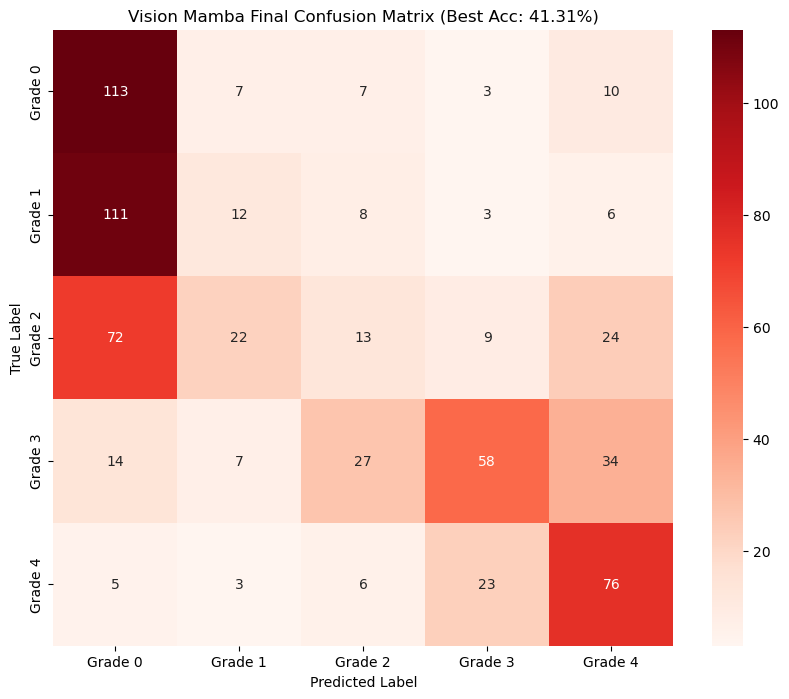

In [4]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import timm

# --- Configuration (Must match training setup) ---
MODEL_NAME = 'mambaout_small' 
NUM_CLASSES = 5
device = torch.device("cpu") 

# --- 1. Load the Best Model State ---
# Assuming dataloaders and necessary setup variables are still defined
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
# Load the weights from the peak performance epoch
model.load_state_dict(torch.load('best_model_mamba_256_final.pth', map_location=device))
model.eval() # Set model to evaluation mode
model = model.to(device)

# --- 2. Generate Predictions ---
all_preds = []
all_labels = []

# Assuming dataloaders['val'] is the correct validation set loader
with torch.no_grad():
    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 3. Report Results ---
class_names = [f'Grade {i}' for i in range(NUM_CLASSES)]

print("\n" + "="*60)
print(f" FINAL VISION MAMBA CLASSIFICATION REPORT (Best Acc: {best_acc*100:.2f}%)")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Reds', 
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Vision Mamba Final Confusion Matrix (Best Acc: {best_acc*100:.2f}%)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Loading Mamba Model from C:\Users\deyko\Desktop\newdbrdidea\SE\ml_core\best_model_mamba_256_final.pth...

       🩺  FINAL PATIENT DIAGNOSIS REPORT  🩺
LEFT EYE (OS):  No DR (Healthy) (56.5%)
RIGHT EYE (OD): No DR (Healthy) (60.6%)
--------------------------------------------------
✅  RECOMMENDATION: Routine follow-up (Re-screen in 12 months)


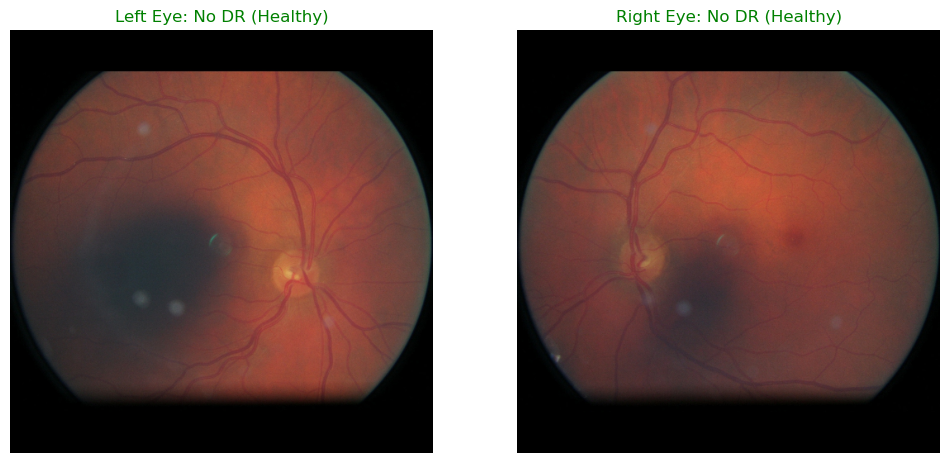

In [5]:
import torch
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# ==========================================
# 1. CONFIGURATION (MUST MATCH Mamba Training)
# ==========================================
# --- UPDATED TO ABSOLUTE PATH ---
MODEL_PATH = r'C:\Users\deyko\Desktop\newdbrdidea\SE\ml_core\best_model_mamba_256_final.pth'
# --------------------------------
MODEL_NAME = 'mambaout_small'
IMG_SIZE = (256, 256)
NUM_CLASSES = 5
device = torch.device("cpu") # Use CPU for inference stability

# Diagnosis Labels
CLASS_LABELS = {
    0: "No DR (Healthy)",
    1: "Mild DR",
    2: "Moderate DR",
    3: "Severe DR",
    4: "Proliferative DR (Critical)"
}

# --- 2. MODEL AND PREPROCESSING SETUP ---

# PyTorch Transforms MUST match your training data pipeline
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def load_mamba_model():
    """Initializes the Mamba model and loads the custom state dict."""
    print(f"Loading Mamba Model from {MODEL_PATH}...")
    try:
        model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
        model.to(device)
        model.eval() # Set to evaluation mode
        return model
    except FileNotFoundError:
        print("❌ Error: Model file not found. Ensure the path is correct.")
        sys.exit()
    except AttributeError:
        # Handles the recurring sympy/torchvision error if it crops up again
        print("❌ CRITICAL ERROR: Environment dependency conflict. Cannot initialize model.")
        sys.exit()


def predict_mamba_grade(left_path, right_path):
    """Generates predictions for two eyes and displays the report."""
    model = load_mamba_model()
    
    # Process and Predict for a single eye
    def get_prediction(path):
        try:
            # 1. Load image and apply transforms
            img_pil = Image.open(path).convert('RGB')
            input_tensor = transform(img_pil).unsqueeze(0).to(device)
            
            # 2. Predict (Disable gradient calculations for speed)
            with torch.no_grad():
                output = model(input_tensor)
            
            probabilities = torch.nn.functional.softmax(output[0], dim=0)
            grade = torch.argmax(probabilities).item()
            conf = torch.max(probabilities).item() * 100
            
            return img_pil, grade, conf
        except FileNotFoundError:
            print(f"❌ Error: Image file not found at {path}")
            return None, None, None
        except Exception as e:
            print(f"❌ Prediction Error on file {path}: {e}")
            return None, None, None

    # Predict Left and Right
    left_disp, grade_l, conf_l = get_prediction(left_path)
    right_disp, grade_r, conf_r = get_prediction(right_path)

    if left_disp is None or right_disp is None:
        print("Report halted due to missing images.")
        return

    # --- PRINT REPORT AND VISUALIZE ---
    print("\n" + "="*50)
    print("       🩺  FINAL PATIENT DIAGNOSIS REPORT  🩺")
    print("="*50)
    print(f"LEFT EYE (OS):  {CLASS_LABELS[grade_l]} ({conf_l:.1f}%)")
    print(f"RIGHT EYE (OD): {CLASS_LABELS[grade_r]} ({conf_r:.1f}%)")
    print("-" * 50)
    
    max_grade = max(grade_l, grade_r)
    if max_grade >= 2:
        print("⚠️  RECOMMENDATION: REFER TO SPECIALIST (Critical/Urgent)")
    else:
        print("✅  RECOMMENDATION: Routine follow-up (Re-screen in 12 months)")
    print("="*50)

    # Show Visual Report
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(left_disp)
    plt.title(f"Left Eye: {CLASS_LABELS[grade_l]}", color='red' if grade_l >= 2 else 'green')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(right_disp)
    plt.title(f"Right Eye: {CLASS_LABELS[grade_r]}", color='red' if grade_r >= 2 else 'green')
    plt.axis('off')

    plt.show()

# --- 4. TEST IT! (Modify these paths) ---
# NOTE: Use paths relative to your script's location.
test_eye_left = r'C:\Users\deyko\Desktop\dbrd\test_images_512\test_images_512\1_left.jpg'
test_eye_right = r'C:\Users\deyko\Desktop\dbrd\test_images_512\test_images_512\1_right.jpg'

predict_mamba_grade(test_eye_left, test_eye_right)